# Lesson129 · Manual feature engineering: what RDL must beat

Student lab · Three TODOs control real feature extraction, validation selection and prediction alignment. Default: train one small course tree and replay all author models. Full50-trial training is explicitly gated. PENDING_WRITTEN_DEFENSE.

<!-- course-portable:start -->
### Follow the computation

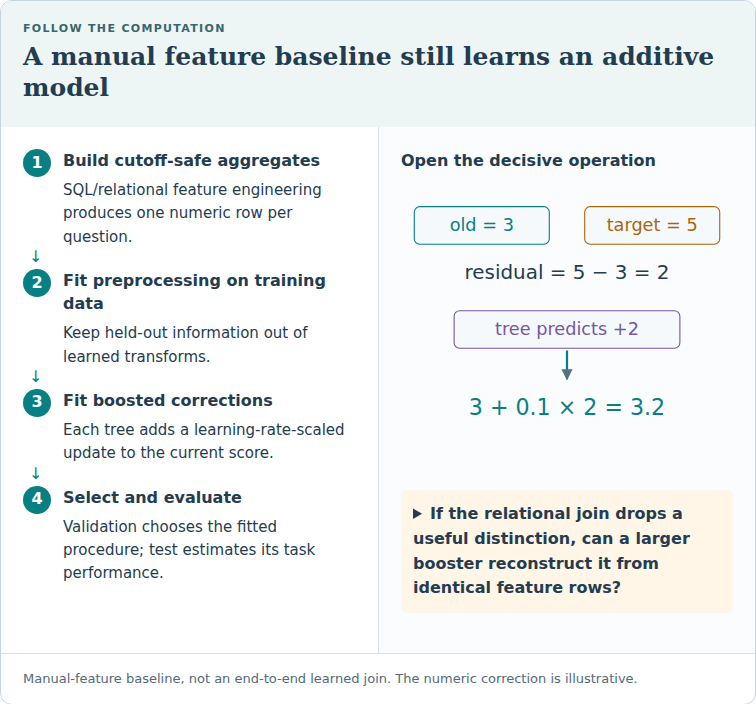

Manual-feature baseline, not an end-to-end learned join. The numeric correction is illustrative.

**Trace question:** If the relational join drops a useful distinction, can a larger booster reconstruct it from identical feature rows?

**Trace answer:** No. Identical model inputs cannot reveal which discarded history produced them.
<!-- course-portable:end -->

In [ ]:
# @colab-bootstrap: only install missing packages for default teaching/replay.
import importlib.util,subprocess,sys
packages={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','sklearn':'scikit-learn','lightgbm':'lightgbm','duckdb':'duckdb','jinja2':'jinja2'}
missing=[v for k,v in packages.items() if importlib.util.find_spec(k) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
import io,json,base64,hashlib,math,zipfile,time
from pathlib import Path
import numpy as np,pandas as pd


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 128 to this lesson</p>
<p>The task taxonomy fixes what to predict. Manual feature engineering is a serious competing way to expose the same relational information.</p>
<details><summary>Quick prerequisite reminder</summary><p>An as-of feature uses only permitted history at the query cutoff. A boosted tree adds successive fitted corrections. Feature design time and machine training time are different costs.</p></details>
</aside>
<!-- sequence-review:end -->

> **The win.** Build and defend a manual-feature baseline that answers the same relational prediction question as a GNN. Trace its inputs, train it without test-guided decisions, and account honestly for the human work behind its features.

[Student lab](https://avistian.github.io/relational/labs/0129-manual-feature-engineering.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0129-manual-feature-engineering.html) · [Reference](https://avistian.github.io/relational/reference/manual-feature-engineering.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l129-reproduction.md) · [Your effort log](https://avistian.github.io/relational/labs/l129-effort-log.md)



## 1 · The baseline must get access to the relationships

[Lesson 128](https://avistian.github.io/relational/lessons/0128-task-taxonomy.html) established the query, target, head, loss and metric. That makes the *question* comparable. It does not make the *information available to competing methods* comparable. A tree trained only on a driver's biographical row cannot exploit race history that a relational GNN receives through its edges.

Our mission is to test whether relational learning earns its complexity. Its meaningful competitor is a capable practitioner who joins useful related information into a flat table and trains a strong tabular model. The skill from [Lesson 009](https://avistian.github.io/relational/lessons/0009-feature-engineering.html) now spans multiple tables; the comparative discipline from [Lesson 127](https://avistian.github.io/relational/lessons/0127-relbench-v1.html) still applies.

The primary reading is [Robinson et al., RelBench v1, §6 and Appendix C](https://arxiv.org/html/2407.20060v1#S6). Read those alongside the [released F1 SQL](https://avistian.github.io/relational/labs/sources/l129/f1/driver-position/feats.sql) and [training script](https://avistian.github.io/relational/labs/sources/l129/train_gbdt.py). **Table 7's LightGBM baseline uses raw entity features. Figure 3's data scientist uses engineered relational features. They are different experiments.** Do not use the Table 7 number as a manual-FE reproduction target.

**Study evidence.** One experienced data scientist explored databases, proposed features, implemented SQL, and supplied feature tables to a standardized tuned LightGBM pipeline. Exploration was capped at four hours and ideation at one hour; SQL implementation time was uncapped and recorded. The paper reports 96% less marginal human work for RDL on average. Reusable infrastructure was excluded, as was the brief optional post-hoc analysis. This is a result under that study's conditions, not a universal multiplier for every practitioner, task or modern assisted workflow. [§6 protocol and results](https://arxiv.org/html/2407.20060v1#S6).



## 2 · Start from a feature hypothesis, not a join

The selected task is `rel-f1/driver-position`: for a driver at cutoff **t**, predict mean finishing position over **(t, t + 60 days]**. Smaller MAE is better. We retain all **7,453 training, 499 validation and 760 test queries**. The released cohort conditions on future participation; a driver with no recorded future race does not receive a zero position. That limitation from [Lesson 124](https://avistian.github.io/relational/lessons/0124-entity-task-tables.html) remains.

Ask what could be predictive before touching SQL:

| Hypothesis | Candidate feature | Required relation | Failure to guard against |
|---|---|---|---|
| Recent form persists | Positions in recent races | driver → results → races | Using a result after t |
| Team strength matters | Latest constructor standings | driver → results → constructor standings | Joining the wrong season or constructor |
| Current standing captures accumulated performance | Driver points and position | driver → standings | Selecting the final season standing |
| Race context matters | Upcoming circuit and round | races → circuits | Assuming the future schedule was already published |
| Experience or identity helps | Age, nationality, driver identity | driver row | Treating an arbitrary numeric ID as a measured quantity |

**Predict.** Which hypothesis needs event history, and which needs evidence of publication time? A future race date can be legitimate input if its schedule was known at t. A future result cannot be used merely because its date appears in the same race row. Availability belongs to a *fact*, not automatically to its entire table.

<figure class="stream-figure" tabindex="0">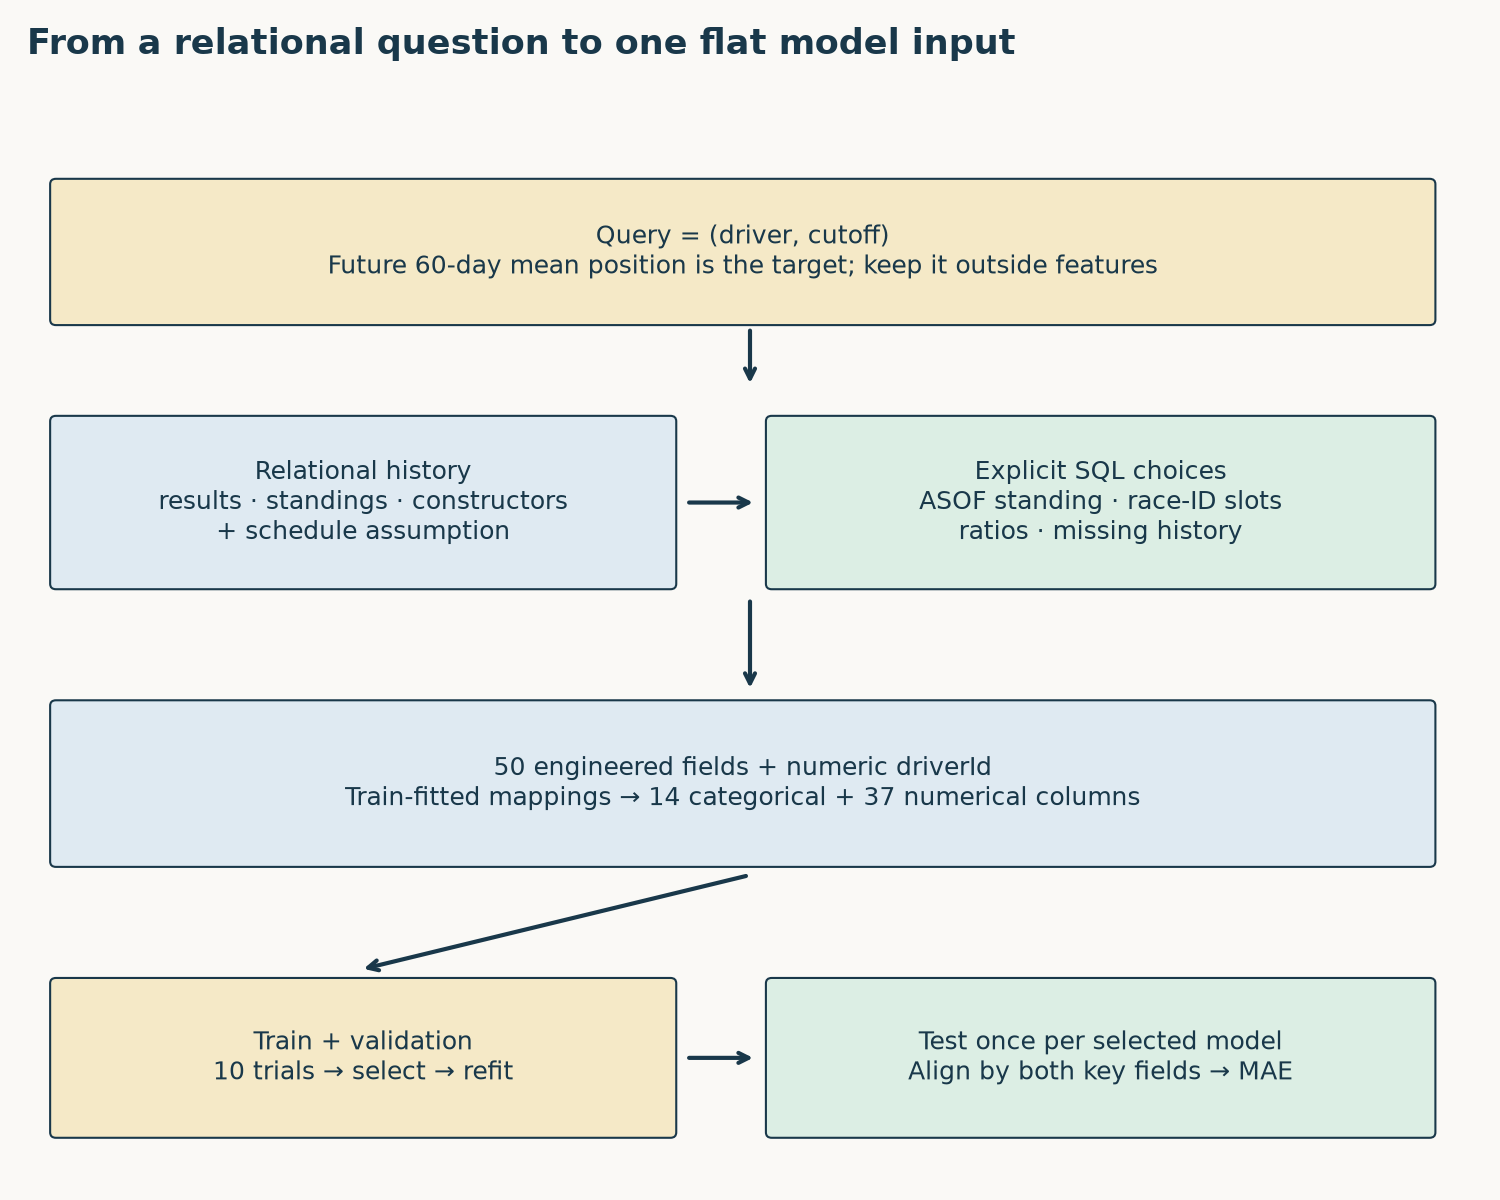<figcaption>The target stays outside features. Explicit relational SQL yields 50 features plus retained numeric driverId; train-fitted mappings feed ten-trial selection and keyed test scoring.</figcaption></figure>

**Before opening the solution**, propose one feature and record why it might help. Start your [effort log](https://avistian.github.io/relational/labs/l129-effort-log.md). Record active human minutes separately from machine seconds and identify reused setup. A log with unknown time is incomplete; an empty entry is not zero.



## 3 · Trace the released SQL into one feature row

The SQL first identifies the last observed driver standing, using an **ASOF left join**: among matching driver rows, select the closest date **strictly before** the query cutoff. A left join retains queries with no matching history and leaves their feature values missing. An inner join would silently change the evaluated cohort.

```sql
ASOF LEFT JOIN standings2
  ON labels.driverId = standings2.driverId
 AND labels.date > standings2.date
```

The last standing identifies a race; that race and driver identify a result; the result identifies the constructor. The constructor's standing at that same race supplies team strength. For example, `points_ratio = driver_points / NULLIF(constructor_points, 0)` returns missing when division by zero would otherwise occur. Missing history and a genuinely zero number of points express different facts.

The released pipeline also uses three past race slots and three upcoming race slots. **These are positions in race-ID arithmetic, not the driver's last three participations.** Past slot i has ID `last_race_id − i + 1` and must lie within the previous two calendar months. If the driver skipped that race, the slot is missing. Upcoming slots have IDs `last_race_id + i` and are restricted to the next calendar month. Calendar months here differ from the target's fixed 60 days.

<figure class="stream-figure" tabindex="0">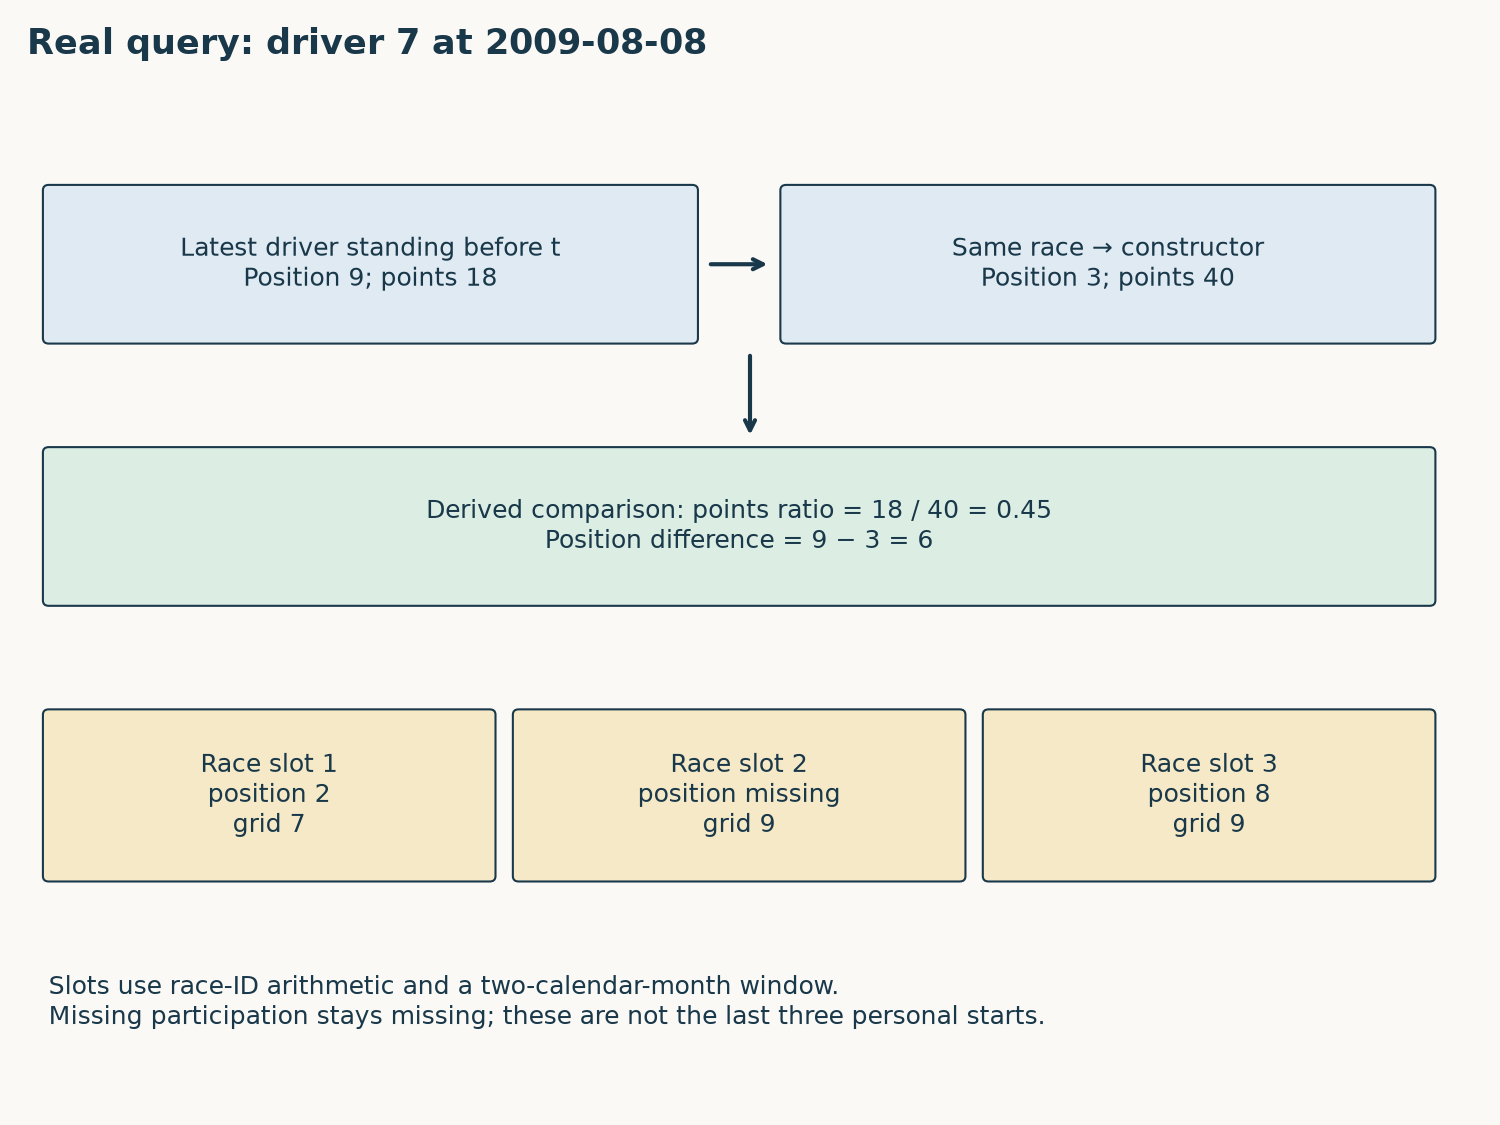<figcaption>Actual driver7 at2009-08-08: points ratio18/40=.45, standing difference9−3=6. Recent race slots use global race IDs.</figcaption></figure>

For driver **7** at **2009-08-08**, driver points **18** and constructor points **40** give **0.45**. Driver standing **9** minus constructor standing **3** gives **6**. Past slot 2 has a recorded grid but missing finishing position: missing values need not mean the whole row is absent.

**A subtle aggregate.** `pct_laps_completed` divides a driver's laps by the maximum laps among eligible joined result rows for that race, within the split's feature-generation query. It is not explicitly the maximum over every driver in the raw race. The release also calls `position − grid` a position gain: a **negative** value indicates moving up. Read computations instead of trusting feature names.

**Audit result.** An independent Python/pandas reconstruction matches **all 443,552 SQL output values checked**: 50 engineered values per query plus train/validation targets. It also independently reconstructs all 8,712 targets from raw future race results. The audit verifies all 11,892 past-result links precede their query. It finds 12,773 upcoming-schedule links, whose publication times are unavailable. [Complete audit](https://avistian.github.io/relational/labs/evidence/l129/sql-audit.json).

The released database loader caps dated rows at **2010-01-01**. Even later test queries receive this frozen database. As a result, this replay has **no recent past-slot or upcoming-slot features for the 760 test queries**, although older cumulative standings remain. That is a material distribution change, not something to quietly repair in a reproduction. Static attributes and actual arrival histories are also unavailable. Matching the SQL does not establish full point-in-time validity.



## 4 · Implement a feature you can reason about

The student function `past_summary` is a deliberately simpler, separate feature hypothesis: count, mean position, and recency in a fixed lookback window. It requires both event time and arrival time. In the illustration, cutoff t = 10 and lookback = 8 select event days in **(2,10)** whose arrival is no later than 10.

- A value 4 at event day 5, arrival day 5 is eligible.
- A value 2 at event day 9, arrival day 10 is eligible.
- A value 99 at event day 8, arrival day 11 is unavailable.
- A value 88 at event day 10 is excluded by the strict-past contract.

Therefore count = 2, mean = (4 + 2)/2 = **3**, and recency = 10 − 9 = **1 day**. If no history exists, return missing, not a fabricated zero finishing position.

**What the summary discards.** Keep the same cutoff 10, lookback 8 and two event days 5 and 9; both events arrive on their event day. Compare two histories for the same driver:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Positions at days 5, 9</th><th>Count</th><th>Mean</th><th>Recency</th></tr></thead><tbody><tr><td>2, 4</td><td>2</td><td>3</td><td>1 day</td></tr><tr><td>3, 3</td><td>2</td><td>3</td><td>1 day</td></tr></tbody></table>

The three-feature vectors are identical, even though the first history worsens and the second stays constant. A tree receiving only these summaries cannot distinguish the histories; adding more trees cannot recover discarded order or variation. This is a limitation of this particular feature map, not proof that a GNN will predict better. The released 50-feature baseline exposes different information.

**Try one change.** Add the latest observed position. It is 4 versus 3 here, so the histories become distinguishable. Explain why that establishes extra information, but does not establish lower held-out MAE. Propose the comparison before looking at test results.

Static cutoff trace: at day10 with an8-day lookback, event/arrival pairs(5,5) and(9,10) yield values4 and2: count2,mean3,recency1. Ignoring arrival admits99 and changes mean to35. Including the event at cutoff admits88 and changes mean to31.333.

**TODO 1.** Implement this filter and aggregation. In the notebook, your function constructs features for **every real query**, and a small depth-three tree trains on those features. That is a course experiment, separate from the released 50-feature baseline. For the real data we can only assume arrival equals event time; the notebook labels this assumption explicitly. The synthetic late-arrival case tests a guarantee the archival database cannot verify.

**CHECK.** Future rows must not change a past summary; changing an arrival from day 10 to day 11 can. Defend each boundary before running the checker.



## 5 · Model architecture: an additive tree ensemble

The SQL produces 53 train/validation columns: two query keys, one target and 50 engineered features. The training script creates a variable listing identifier columns but never actually removes them. Numeric `driverId` enters the model. The timestamp is materialized by PyTorch Frame but ignored by its LightGBM input adapter. The final matrices are **7,453 × 51**, **499 × 51** and **760 × 51**: 14 categorical columns followed by 37 numerical columns.

Preprocessing learns categories from training rows, then uses the same mappings on validation and test. Unknown categorical values use the mapping's missing/unknown representation; numerical NaNs stay missing. Tree nodes can route missing values along a learned default branch. Test rows do not fit these mappings. Inspect the visible [input adapter](https://avistian.github.io/relational/labs/sources/l129/frame/tuned_lightgbm.py), not just a declaration of the feature schema.

A boosted tree model predicts an additive sum:

**prediction(x) = leaf₁(x) + leaf₂(x) + … + leafₘ(x)**.

Each tree routes a row through threshold or category tests and returns a leaf contribution. In the saved LightGBM representation, leaf values already include the relevant scaling; the first tree also carries the initial prediction. Do not multiply them by the learning rate again. Later contributions can be negative. The regression objective is **L1 / absolute error**, matching validation MAE. This is not a neural network trained by the GNN optimizer.

<figure class="stream-figure" tabindex="0">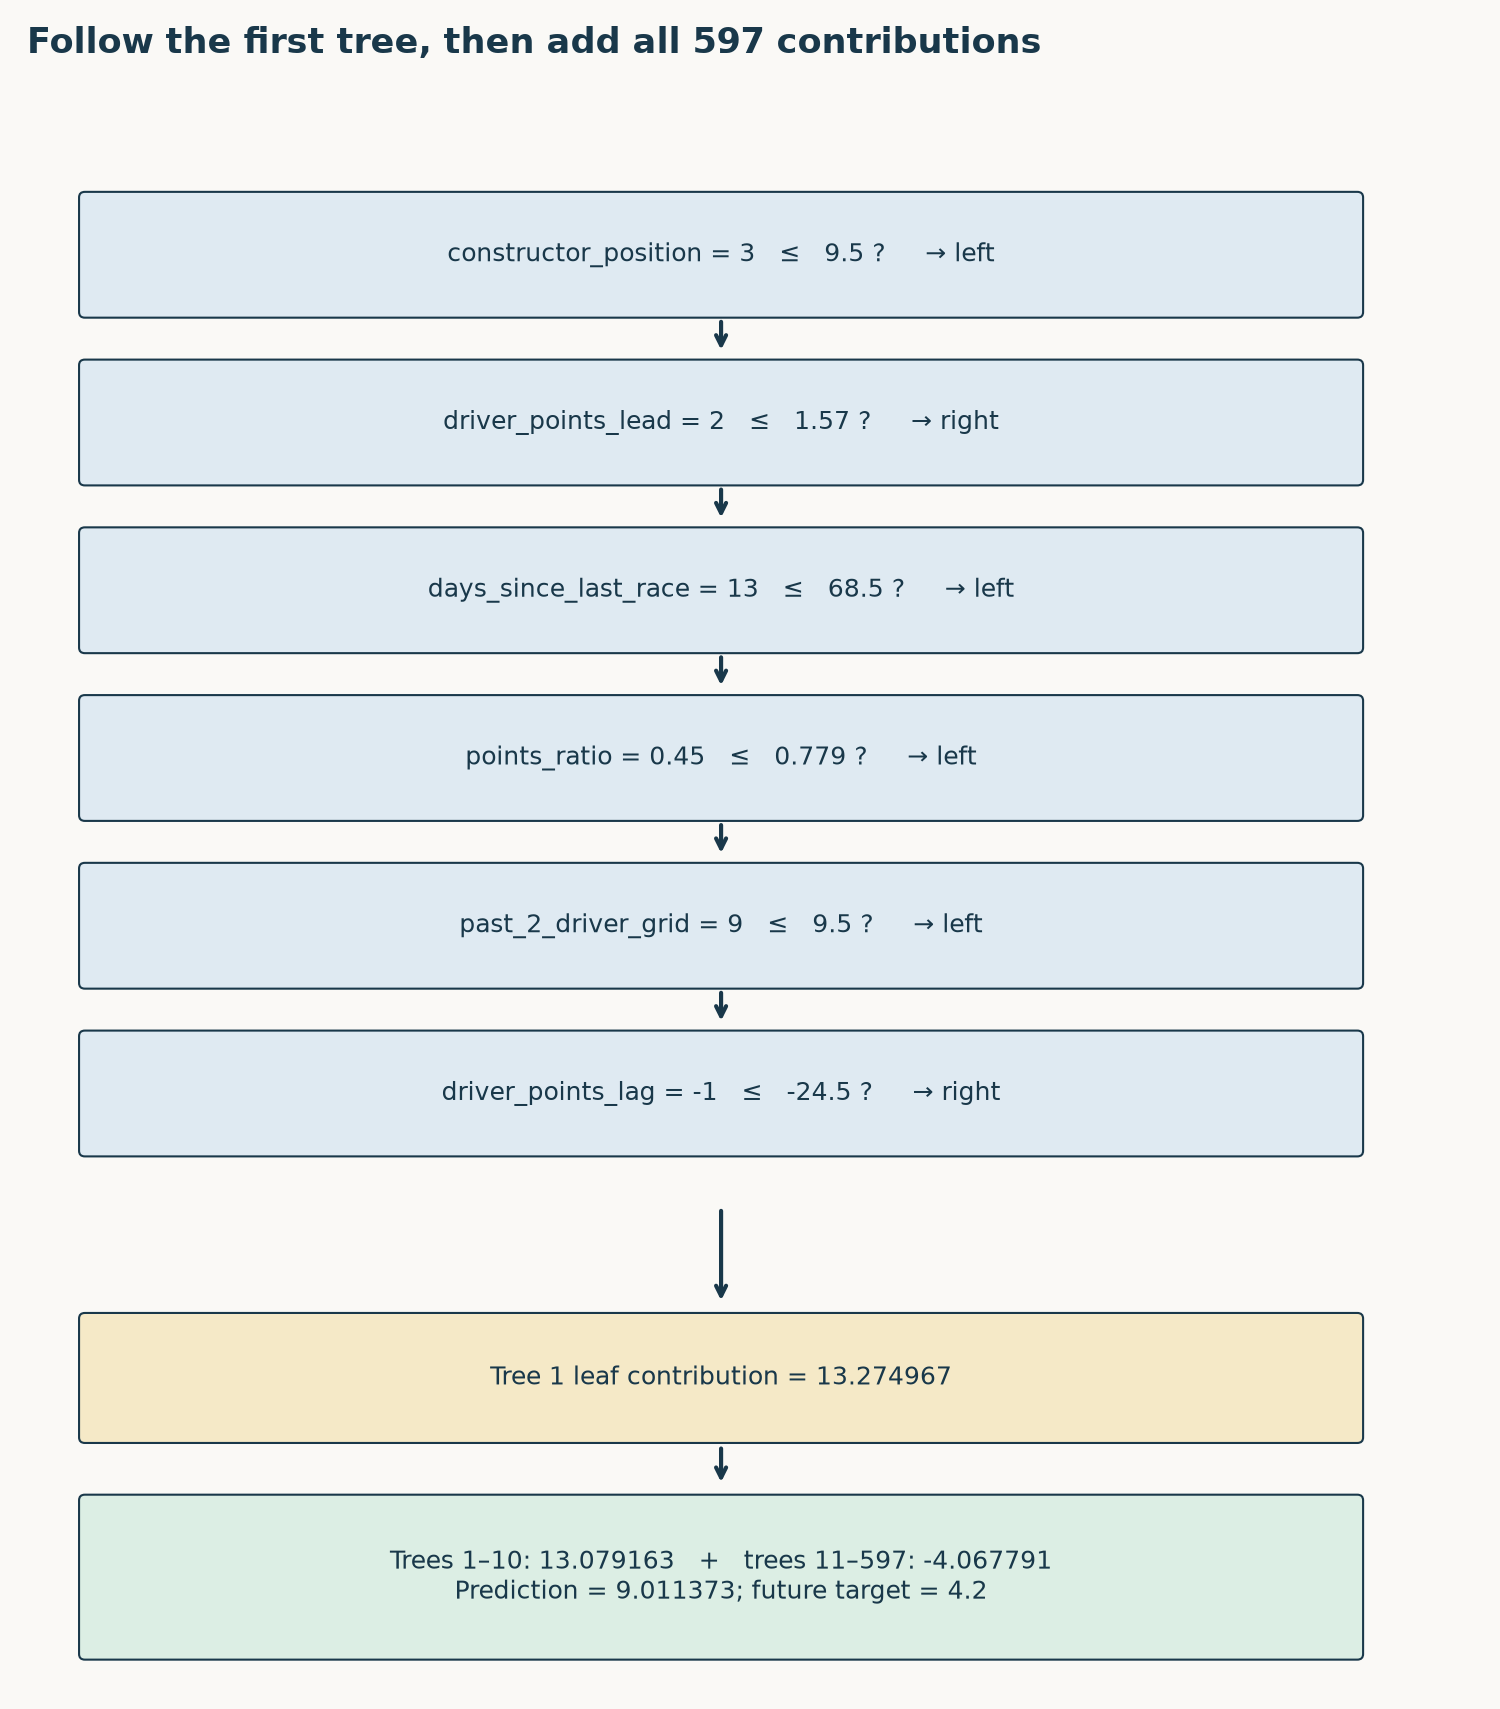<figcaption>Actual seed0 first-tree decisions and full ensemble sum. Leaf contributions already include scaling; do not multiply by the learning rate again.</figcaption></figure>

In seed 0, this row follows **6** tests in the first tree and reaches leaf **13.274967**. The first ten trees sum to **13.079163**; the remaining **587** contribute **-4.067791**. Total prediction **9.011373**, target **4.2**, absolute error **4.811373**. The error is large on this row even though the model's aggregate MAE is lower. [Machine-readable trace](https://avistian.github.io/relational/labs/evidence/l129/prediction-trace.json).

**Predict.** Can the leaf of the first tree alone be interpreted as the final finishing-position prediction? No: every selected tree contributes. Can a low error on this one row establish a strong model? No: the reported score averages the complete held-out cohort.



## 6 · Tune on validation, then align by query identity

The release searches **10 configurations**, using Optuna's default TPE sampler. Its first ten startup trials sample the parameter space before adaptive TPE proposals. Each configuration allows up to **2,000 trees**, with **50-round validation early stopping**. Search dimensions include depth, learning rate, leaves, row and column subsampling, L1/L2 regularization and minimum leaf size. The selected configuration is fitted again on the training set using validation early stopping; validation rows are not added to the training labels. [Pinned trainer](https://avistian.github.io/relational/labs/sources/l129/frame/tuned_lightgbm.py).

```python
def tune_fe(matrices,seed,num_trials=10,rounds=2000,threads=4):
    import lightgbm as lgb
    import optuna
    train_x,train_y,cats=matrices['train'];val_x,val_y,_=matrices['val']
    train=lgb.Dataset(train_x,label=train_y,free_raw_data=False)
    val=lgb.Dataset(val_x,label=val_y,free_raw_data=False)
    trace=[]
    study=optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=seed))
    def fit(params):
        return lgb.train(dict(params,num_threads=threads),train,num_boost_round=rounds,
            categorical_feature=cats,valid_sets=[val],callbacks=[lgb.early_stopping(50,verbose=False),lgb.log_evaluation(0)])
    def objective(trial):
        start=time.perf_counter();params=sample_parameters(trial);model=fit(params)
        pred=model.predict(val_x);score=float(np.mean(np.abs(pred-val_y)))
        trace.append(dict(number=trial.number,val_mae=score,best_iteration=model.best_iteration,params=params,seconds=time.perf_counter()-start))
        return score
    study.optimize(objective,n_trials=num_trials)
    selected=choose_trial(trace);assert selected==study.best_trial.number
    best=next(row for row in trace if row['number']==selected)
    model=fit(best['params']) # upstream refits the selected configuration
    assert abs(float(np.mean(np.abs(model.predict(val_x)-val_y)))-best['val_mae'])<1e-10
    return model,trace,selected
```

The original SQL also leaves output order unspecified. We freeze rows to the archived task-query order before fitting: row-subsampling depends on order even when a random seed is fixed. A failing order check exposed this during the full notebook rerun; both one-thread and four-thread SQL extraction now produce identical ordered feature tables. [Order check](https://avistian.github.io/relational/labs/_order_check_l129_results.json).

The original script does not seed that search. We explicitly use seeds **0–4** for five fresh searches, fix the input row order, and retain the boosting library's other defaults. The resulting standard deviation measures variation across searches. It is not a confidence interval, and the runs are not five trials from one larger 50-configuration contest. Each run gets its own fixed ten-trial budget.

**TODO 2.** Implement `choose_trial`: select minimum validation MAE, break ties by earliest trial number, reject missing/nonfinite evidence. Changing a test score must not change the selection.

SQL can reorder rows. A correct numerical prediction paired with the wrong target is still wrong. The key is **(driverId, cutoff)**, not driver ID alone. Reject duplicate keys, missing queries and nonfinite predictions before scoring.

**TODO 3.** Implement `align_predictions`. The notebook uses your function to align and rescore all five author runs. Its fixture deliberately queries one driver twice to expose entity-only lookup. Independent checks must not merely compare array lengths.

**CHECK.** Six deliberate mistakes are rejected: admitting cutoff-time events, ignoring arrival times, admitting the lower-window endpoint, assuming positional alignment, selecting on test, and breaking validation ties with the last trial. [Mutation evidence](https://avistian.github.io/relational/labs/_mutation_l129_results.json).



## 7 · What the completed reproduction establishes

**Five complete fresh searches, ten trials each.**

| Split | Manual FE mean MAE | Sample SD | L127 RDL mean MAE | FE − RDL |
|---|---:|---:|---:|---:|
| val | 2.777330 | 0.027905 | 3.178174 | -0.400844 |
| test | 3.948917 | 0.070469 | 3.967165 | -0.018248 |

| Search seed | Selected trial | Trees | Validation MAE | Test MAE |
|---|---:|---:|---:|---:|
| 0 | 5 | 597 | 2.744086 | 3.921045 |
| 1 | 5 | 158 | 2.816721 | 4.042601 |
| 2 | 8 | 476 | 2.773399 | 3.852457 |
| 3 | 9 | 459 | 2.791052 | 3.980605 |
| 4 | 5 | 317 | 2.761390 | 3.947876 |

All **6,295 predictions** independently checked. Five searches and their selected refits took **37.60 seconds** inside the local worker processes; pilot, startup, preparation and audits are separate. **Paid cloud spend: USD 0.** Seed SD is descriptive, not a confidence interval.

All five searches use the full task and released feature set. The standalone full-training notebook gate was also executed in the pinned runtime: it rebuilt SQL and preprocessing, repeated all50 trials and five refits, and matched all6,295 final predictions exactly. [Full-gate verification](https://avistian.github.io/relational/labs/_gate_l129_results.json). Independent tree traversal reproduces every final validation/test prediction; a separate SQLite calculation recomputes all MAEs. The source-parity pilot used the **original, byte-matched PyTorch Frame 0.2.2 trainer**, with seeded search and four threads, and produced exactly matching predictions. [Source check](https://avistian.github.io/relational/labs/_source_check_l129_results.json) · [Full evidence](https://avistian.github.io/relational/labs/evidence/l129/summary.json).

<figure class="stream-figure" tabindex="0">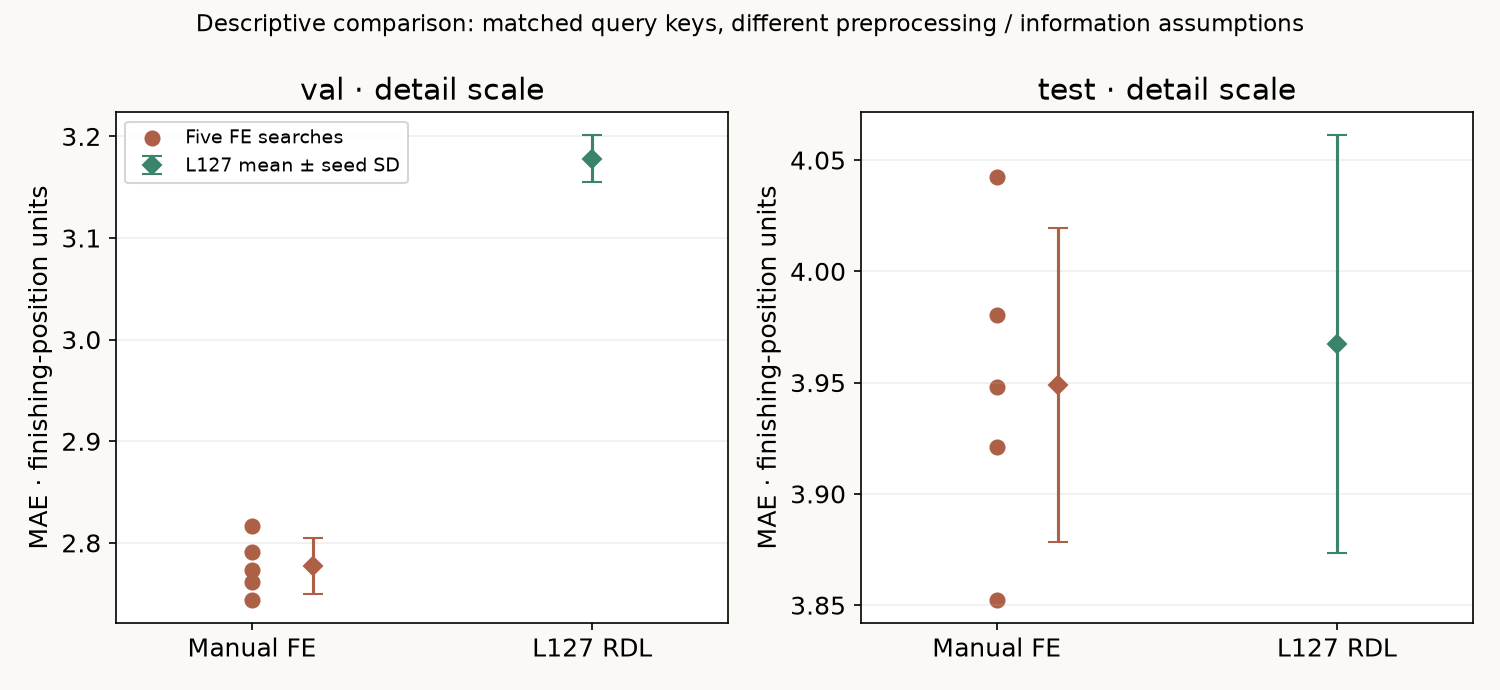<figcaption>Five complete FE searches compared descriptively with existing L127 RDL. Detail scales; bars show sample seed SD, not confidence intervals.</figcaption></figure>

The L127 comparison uses the same query keys and labels, with only the recorded float32 rounding difference. Nevertheless, it is a **descriptive course comparison**: FE uses train-fitted preprocessing, while the released RDL preprocessing fits through the test cutoff; FE also uses schedule fields whose historical availability is unverified. L127 is the basic RDL model, whereas the user-study regression comparison discusses an improved/boosted head in Appendix C. Do not equate the two comparators.

The selected released computational pipeline is complete. **Historical paper-score parity remains NOT_ESTABLISHED.** The old `relbench==0.2.0` staging endpoint returns 404, so we use pinned v1 archives whose split dimensions agree with the released notebook. Exact historical archive identity, original unseeded search draws and saved model are unavailable. Figure 3 supplies normalized bars rather than the exact task scalar used here. We do not infer an exact target from a plotted bar or substitute Table 7's unrelated LightGBM score.

**Full human-study reproduction is NOT_RUN.** All other tasks and new human participants are outside this selected experiment. These are boundaries on the claim, not reasons to hide an executable full-data result. [Protocol, source versions, deviations and commands](https://avistian.github.io/relational/labs/l129-reproduction.md).



## 8 · Measure effort without changing its meaning

The important distinction is between *inventing and implementing features* and *executing features that already exist*. This replay begins after someone supplied the SQL. Its machine runtime cannot estimate how long discovery took. An assistant's authoring time is not an unassisted expert's work, either.

<figure class="stream-figure" tabindex="0">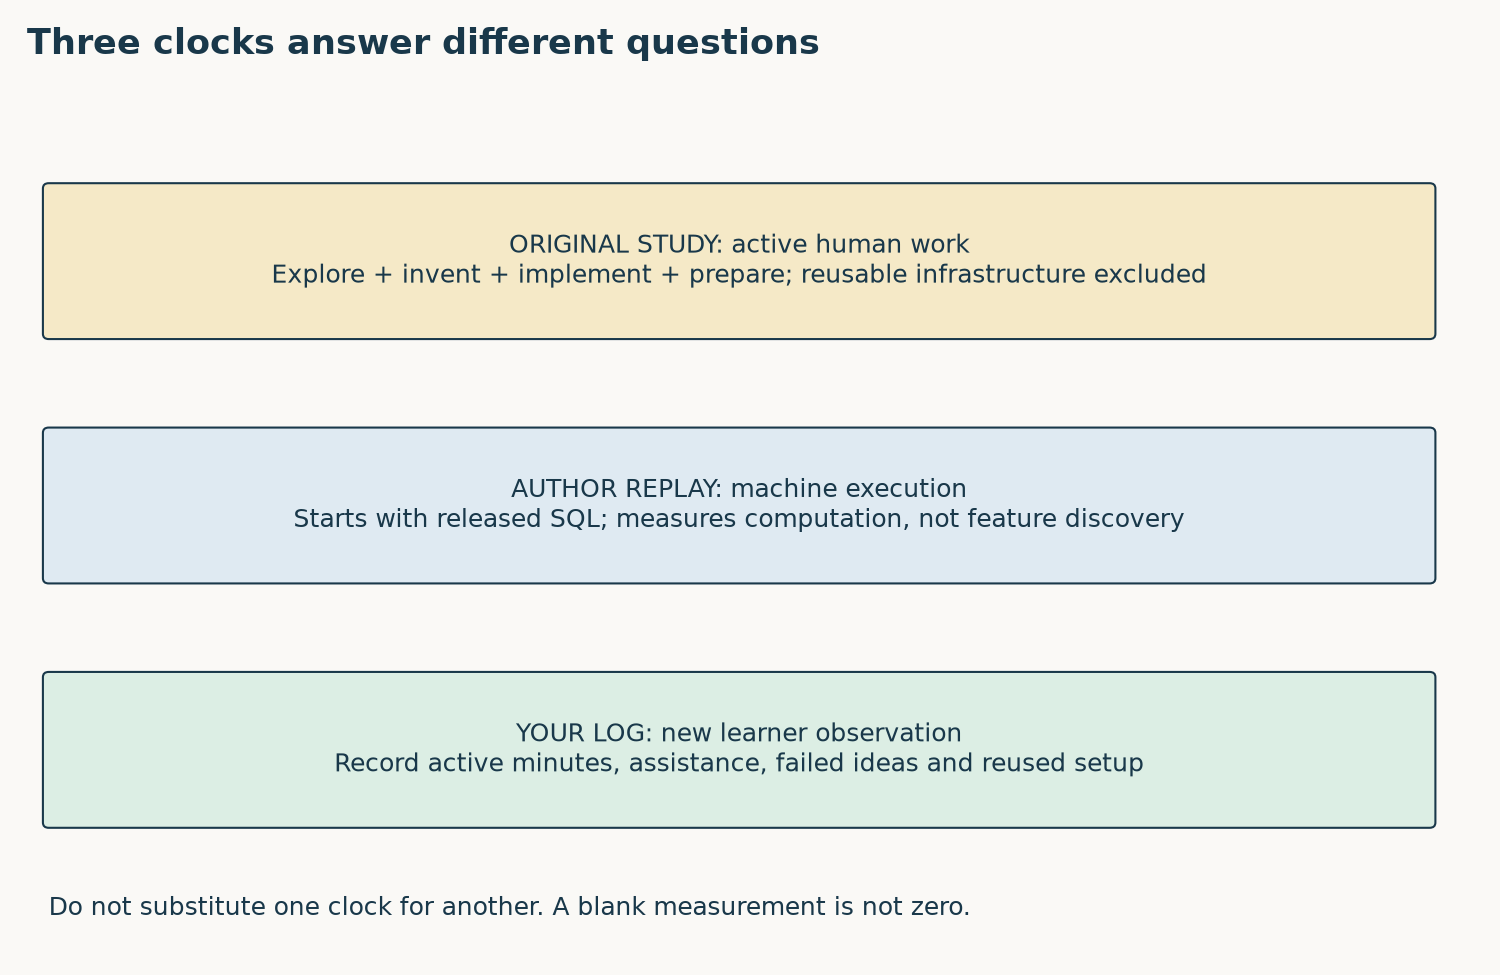<figcaption>Original human work, automated replay runtime and a new learner effort log measure different activities.</figcaption></figure>

In your log, keep exploration, ideation, SQL/debugging, input preparation and evaluation visible. Record whether each component is reusable or task-specific. Include failed ideas and assistance. Compare performance only after fixing a validation-based workflow and a feature-development budget. A new learner observation contributes evidence about that new setting; it cannot recreate the original participant.

**Wisdom exercise.** Ask a practitioner to review one feature's availability assumption and one excluded effort category. Bring the precise query and SQL to the [RelBench repository](https://github.com/snap-stanford/relbench), rather than arguing from the headline percentage alone. No message is sent by this lesson.

Write your answer about human effort before checking the evidence.



## 9 · EXIT: defend the competitor

Submit the three implementations, your notebook report and your actual effort log. Then answer without copying the solution:

1. Trace one query through standings, constructor joins, recent race slots, categorical encoding and the ensemble sum. Identify where information is compressed.
2. Explain why a future schedule can be valid while a future result leaks, and what historical metadata is missing here.
3. Explain why the released trainer has 51 input columns, and why the test cohort has no recent race-slot features in this replay.
4. Show how you prevented test-guided selection and keyed predictions by both entity and cutoff.
5. State exactly which reproduction is complete, which identities remain unestablished, and why runtime does not reproduce human effort.

Passing the author's notebook is not evidence of your mastery: **PENDING_WRITTEN_DEFENSE**. Tomorrow, reconstruct the cutoff test and query key from memory; next week, design one different feature before rereading the SQL. Lesson 130 will use this defensible baseline in an end-to-end checkpoint. Ask your teaching agent about any join, tree branch, experiment result or evidence boundary that remains unclear.

<!-- sequence-next:start -->
**Carry this forward.** Assemble the complete RDL pipeline and defend it against this comparison. [Continue to Lesson 130](https://avistian.github.io/relational/lessons/0130-rdl-checkpoint.html).
<!-- sequence-next:end -->


In [ ]:
def rejected(fn,*args):
    try:fn(*args)
    except ValueError:return
    raise AssertionError('Invalid input accepted')

## TODO · past_summary

Filter by entity, strict event window and arrival cutoff; return missing for no history.

In [ ]:
def past_summary(events, entity, cutoff, lookback):
    raise NotImplementedError("TODO: past_summary")

In [ ]:
def check_past(fn):
    # Event, arrival and value. Same-cutoff races excluded; arrival exactly t allowed.
    rows=[dict(entity=7,event=2,available=2,value=6),dict(entity=7,event=5,available=5,value=4),dict(entity=7,event=9,available=10,value=2),dict(entity=7,event=8,available=11,value=99),dict(entity=7,event=10,available=10,value=88),dict(entity=8,event=8,available=8,value=77)]
    assert fn(rows,7,10,8)==dict(count=2,mean=3.0,days_since_latest=1)
    assert fn(rows,9,10,8)==dict(count=0,mean=None,days_since_latest=None)
    assert fn(rows,7,10,1)==dict(count=0,mean=None,days_since_latest=None)
    future=rows+[dict(entity=7,event=12,available=12,value=-1000)]
    assert fn(rows,7,10,8)==fn(future,7,10,8)
    rejected(fn,rows,7,10,0)
check_past(past_summary)
print("PASS: past_summary")

## TODO · choose_trial

Choose earliest validation minimum; test scores cannot influence selection.

In [ ]:
def choose_trial(trials):
    raise NotImplementedError("TODO: choose_trial")

In [ ]:
def check_select(fn):
    trials=[dict(number=0,val_mae=3.2,test_mae=9),dict(number=1,val_mae=3.0,test_mae=8),dict(number=2,val_mae=3.0,test_mae=1)]
    assert fn(trials)==1
    assert fn(list(reversed(trials)))==1
    for row in trials:row['test_mae']=-row['test_mae']
    assert fn(trials)==1
    rejected(fn,[]);rejected(fn,[dict(number=0,val_mae=float('nan'))])
    rejected(fn,[dict(number=0,val_mae=1),dict(number=0,val_mae=2)])
check_select(choose_trial)
print("PASS: choose_trial")

## TODO · align_predictions

Validate complete unique query keys, then reorder by(entity,cutoff).

In [ ]:
def align_predictions(feature_keys, predictions, query_keys):
    raise NotImplementedError("TODO: align_predictions")

In [ ]:
def check_align(fn):
    # Same entity at two cutoffs proves entity-only lookup is wrong.
    keys=[(7,20),(8,10),(7,10)];pred=[2.,8.,1.];q=[(7,10),(7,20),(8,10)]
    assert fn(keys,pred,q)==[1.,2.,8.]
    rejected(fn,keys,[2,8],q)
    rejected(fn,keys,pred,[(7,10)])
    rejected(fn,[(7,10),(7,10)],[1,2],[(7,10),(8,10)])
    rejected(fn,keys,[2,float('nan'),1],q)
    rejected(fn,keys,pred,[(7,10),(7,10),(8,10)])
check_align(align_predictions)
print("PASS: align_predictions")

## PROVIDED · complete pinned inputs

No repository imports or network downloads for data. The bundle contains all raw tables, all task rows, all feature matrices, five trained models and every held-out prediction.

In [ ]:
# PROVIDED: full archives, matrices, five models and every held-out prediction.
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='748cfa7c0a2697a0b9f0d8532844e79b88b39338ca4391786098d78e24c01637'
root=Path('l129-portable');root.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
 for name in z.namelist():
  assert not Path(name).is_absolute() and '..' not in Path(name).parts
  p=root/name;p.parent.mkdir(parents=True,exist_ok=True);p.write_bytes(z.read(name))
source=root/'sources/l129';evidence=root/'evidence/l129'
print('Verified complete portable bundle:',len(raw),'bytes')


## COURSE · train a tree on your features

Uses result positionOrder, strict60-day lookback, assumed arrival=event, frozen2010 database and a fixed depth-three tree. No tuning, no paper-score claim.

In [ ]:
# YOUR past_summary constructs all8,712 real-query inputs for a small course tree.
from sklearn.tree import DecisionTreeRegressor
start=time.perf_counter()
with zipfile.ZipFile(source/'db.zip') as z:
 events_df=pd.read_parquet(io.BytesIO(z.read('db/results.parquet')))
events_df=events_df[(events_df.date<=pd.Timestamp('2010-01-01'))].drop_duplicates(['raceId','driverId'])
event_groups={}
for row in events_df.itertuples():
 day=pd.Timestamp(row.date).value/86400e9
 event_groups.setdefault(int(row.driverId),[]).append(dict(entity=int(row.driverId),event=day,available=day,value=float(row.positionOrder)))
labels={}
with zipfile.ZipFile(source/'driver-position.zip') as z:
 for split in ['train','val','test']:labels[split]=pd.read_parquet(io.BytesIO(z.read('driver-position/'+split+'.parquet')))
fill_mean=float(labels['train'].position.median());X={};checked=0
for split,frame in labels.items():
 rows=[]
 for q in frame.itertuples():
  t=pd.Timestamp(q.date).value/86400e9;events=event_groups.get(int(q.driverId),[])
  got=past_summary(events,int(q.driverId),t,60)
  # Independently vectorized expected contract on real history.
  days=np.array([e['event'] for e in events]);values=np.array([e['value'] for e in events]);mask=(days>t-60)&(days<t)
  assert got['count']==int(mask.sum())
  if mask.any():
   assert abs(got['mean']-float(values[mask].mean()))<1e-10
   assert abs(got['days_since_latest']-(t-days[mask].max()))<1e-10
  else:assert got['mean'] is None and got['days_since_latest'] is None
  rows.append([got['count'],fill_mean if got['mean'] is None else got['mean'],61 if got['days_since_latest'] is None else got['days_since_latest']]);checked+=1
 X[split]=np.array(rows)
course_model=DecisionTreeRegressor(max_depth=3,random_state=129)
course_model.fit(X['train'],labels['train'].position)
course_scores={s:float(np.mean(np.abs(course_model.predict(X[s])-labels[s].position))) for s in ['val','test']}
print('COURSE_ONLY:',course_scores,'queries',checked,'seconds',time.perf_counter()-start)
print('Arrival=event is an explicit assumption. This small tree is NOT the released50-feature experiment.')


## REPLAY · independently traverse every saved tree

Provided tree traversal is distinct from LightGBM prediction; your alignment and selection functions are used on every search.

In [ ]:
def tree_predict(node,x,rows):
    if 'leaf_value' in node:return np.full(len(rows),node['leaf_value'])
    v=x[rows,node['split_feature']];missing=np.isnan(v)
    if node['decision_type']=='==':
        missing|=v<0
        left=np.isin(v,[int(t) for t in node['threshold'].split('||')])
    else:
        if node['missing_type']=='Zero':missing|=v==0
        left=v<=float(node['threshold'])
    left[missing]=node['default_left'];out=np.empty(len(rows))
    if left.any():out[left]=tree_predict(node['left_child'],x,rows[left])
    if (~left).any():out[~left]=tree_predict(node['right_child'],x,rows[~left])
    return out

In [ ]:
# YOUR selection and alignment plus independent saved-tree evaluation.
import lightgbm as lgb,statistics
arrays=np.load(evidence/'matrices.npz',allow_pickle=False)
summary=json.loads((evidence/'summary.json').read_text());scores=[];count=0;tree_error=0
for seed in range(5):
 folder=evidence/f'paper/seed-{seed}';r=json.loads((folder/'result.json').read_text());pred=np.load(folder/'predictions.npz')
 assert choose_trial(r['trace'])==r['selected_trial']
 model=lgb.Booster(model_file=str(folder/'model.txt'));trees=model.dump_model()['tree_info'];row={}
 for split in ['val','test']:
  x=arrays[split+'_x'];raw=sum(tree_predict(t['tree_structure'],x,np.arange(len(x))) for t in trees)
  error=float(np.max(np.abs(raw-model.predict(x,num_threads=2))));assert error<1e-10;tree_error=max(tree_error,error)
  fk=list(zip(arrays[split+'_feature_id'],arrays[split+'_feature_time']));qk=list(zip(arrays[split+'_query_id'],arrays[split+'_query_time']))
  aligned=np.array(align_predictions(fk,raw,qk));np.testing.assert_allclose(aligned,pred[split+'_pred'],rtol=0,atol=1e-10)
  # Deliberately reverse feature order: key-based output must stay identical.
  assert align_predictions(fk[::-1],raw[::-1],qk)==aligned.tolist()
  score=math.fsum(abs(float(y)-float(p)) for y,p in zip(pred[split+'_target'],aligned))/len(aligned)
  assert abs(score-r['scores'][split])<1e-12;row[split]=score;count+=len(aligned)
 scores.append(row);print('Search',seed,'selected',r['selected_trial'],'MAE',row)
aggregate={s:dict(mean=statistics.mean(r[s] for r in scores),sample_sd=statistics.stdev(r[s] for r in scores)) for s in ['val','test']}
for s in aggregate:
 for k in aggregate[s]:assert abs(aggregate[s][k]-summary['metrics'][s][k])<1e-12
report=dict(status='PASS',predictions=count,real_course_queries=checked,course_scores=course_scores,aggregate=aggregate,maximum_tree_error=tree_error,scope='Small new course tree + full author model/evidence replay, not50 new fits',learner_status='PENDING_WRITTEN_DEFENSE')
Path('l129-report.json').write_text(json.dumps(report,indent=2));print(report)


## PROVIDED · full released SQL

Read every ASOF join and time predicate. Full template, without feature omissions:

```sql
create or replace table driver_position_{{ set }}_feats as -- noqa

with labels as materialized (
    -- driverId, date, position
    {% if (set == 'train') and (subsample > 0) %} -- noqa
    select * from driver_position_{{ set }} using sample {{ subsample }} -- noqa
    {% else %}
    select * from driver_position_{{ set }} -- noqa
    {% endif %}
),

standings2 as (
    select
        *,
        points - lag(points, 1) over (partition by raceId order by position asc) as points_lag,
        points - lead(points, 1) over (partition by raceId order by position asc) as points_lead
    from standings
),

constructor_standings2 as (
    select
        *,
        points - lag(points, 1) over (partition by raceId order by position asc) as points_lag,
        points - lead(points, 1) over (partition by raceId order by position asc) as points_lead
    from constructor_standings
),

-- results has duplicates
results_dd as materialized (
    select distinct on (raceId, driverId)
        raceId,
        driverId,
        constructorId,
        position,
        points,
        grid,
        rank,
        laps,
        statusId,
        date
    from results
),

basic_feats as (
    select
        labels.driverId,
        labels.date,
        date_part('week', labels.date) as week_of_year,
        -- driver features
        drivers.driverRef as driver_ref, -- use as categorical
        date_diff('year', drivers.dob::date, labels.date) as driver_age,
        drivers.nationality as driver_nationality,
        -- driver standings
        standings2.position as driver_position,
        standings2.points as driver_points,
        standings2.wins as driver_wins,
        standings2.points_lag as driver_points_lag,
        standings2.points_lead as driver_points_lead,
        date_diff('day', standings2.date, labels.date) as days_since_last_race,
        -- constructor features
        constructors.constructorRef as constructor_ref,
        constructors.nationality as constructor_nationality,
        -- constructor standings
        constructor_standings2.position as constructor_position,
        constructor_standings2.points as constructor_points,
        constructor_standings2.wins as constructor_wins,
        constructor_standings2.points_lag as constructor_points_lag,
        constructor_standings2.points_lead as constructor_points_lead,
        -- driver contribution
        driver_position - constructor_position as position_diff,
        driver_points / nullif(constructor_points, 0) as points_ratio,
        driver_wins / nullif(constructor_wins, 0) as wins_ratio
    from labels
    left join drivers
        on labels.driverId = drivers.driverId
    asof left join standings2
        on
            labels.driverId = standings2.driverId
            and labels.date > standings2.date
    left join results_dd -- use it to join constructor_standings
        on
            standings2.raceId = results_dd.raceId
            and labels.driverId = results_dd.driverId
    left join constructor_standings2
        on
            standings2.raceId = constructor_standings2.raceId
            and results_dd.constructorId = constructor_standings2.constructorId
    left join constructors
        on constructor_standings2.constructorId = constructors.constructorId
),

past_race_features as (
    select
        labels.driverId,
        labels.date,
        (last_race.raceId - results_dd.raceId + 1) as races_ago,
        -- results_dd
        results_dd.position as driver_position,
        results_dd.points as driver_points,
        results_dd.grid as driver_grid,
        results_dd.position - results_dd.grid as position_gain,
        results_dd.rank as driver_rank,
        results_dd.laps
        / max(results_dd.laps) over (partition by results_dd.raceId) as pct_laps_completed,
        (results_dd.statusId != 1)::int as dnf,
        -- constructor results_dd
        constructor_results.points as constructor_points
    from labels
    asof left join races as last_race
        on labels.date > last_race.date
    left join results_dd
        on
            labels.driverId = results_dd.driverId
            and (last_race.raceId - results_dd.raceId) between 0 and 2 -- last 3 races
            -- exclude races from last season
            and results_dd.date >= (labels.date - interval '2 month')
    left join constructor_results
        on
            results_dd.raceId = constructor_results.raceId
            and results_dd.constructorId = constructor_results.constructorId
),

upcoming_race_features as (
    select
        labels.driverId,
        labels.date,
        (upcoming.raceId - last_race.raceId) as races_ahead,
        upcoming.round,
        circuits.circuitId
    from labels
    asof left join races as last_race
        on labels.date > last_race.date
    left join races as upcoming
        on
            (upcoming.raceId - last_race.raceId) between 1 and 3 -- next 3 races
            and upcoming.date <= (labels.date + interval '1 month')
    left join circuits
        on upcoming.circuitId = circuits.circuitId
)

select
    labels.driverId,
    labels.date,
    {% if set != 'test' +%} -- noqa
        labels.position,
    {% endif %}
    basic_feats.* exclude(driverId, date),
    {% for i in [1, 2, 3] %}
        past_{{ i }}.driver_position as past_{{ i }}_driver_position,
        past_{{ i }}.driver_points as past_{{ i }}_driver_points,
        past_{{ i }}.driver_grid as past_{{ i }}_driver_grid,
        past_{{ i }}.position_gain as past_{{ i }}_position_gain,
        past_{{ i }}.driver_rank as past_{{ i }}_driver_rank,
        past_{{ i }}.pct_laps_completed as past_{{ i }}_pct_laps_completed,
        past_{{ i }}.dnf as past_{{ i }}_dnf,
        past_{{ i }}.constructor_points as past_{{ i }}_constructor_points,
        upcoming_{{ i }}.round as upcoming_{{ i }}_round,
        upcoming_{{ i }}.circuitId as upcoming_{{ i }}_circuit_id
        {%- if not loop.last %},{% endif %} -- noqa
    {% endfor %}
from labels
left join basic_feats
    on
        labels.driverId = basic_feats.driverId
        and labels.date = basic_feats.date
{% for i in [1, 2, 3] %}
    left join past_race_features as past_{{ i }}
        on
            labels.driverId = past_{{ i }}.driverId
            and labels.date = past_{{ i }}.date
            and past_{{ i }}.races_ago = {{ i }}
    left join upcoming_race_features as upcoming_{{ i }}
        on
            labels.driverId = upcoming_{{ i }}.driverId
            and labels.date = upcoming_{{ i }}.date
            and upcoming_{{ i }}.races_ahead = {{ i }}
{% endfor %}

```

## PROVIDED · complete pipeline implementation

Functions below perform archive validation, snapshot filtering, SQL extraction, train-fitted materialization and full search. The upstream search class is pinned under sources/l129/frame with MIT attribution. In this portable copy, tune_fe uses your choose_trial from the notebook namespace.

In [ ]:
"""Complete released manual-feature experiment, with explicit reproducibility adapters.

SQL: snap-stanford/relbench-user-study 445bb7a3b1230f49f8e5890ae81754d3e365680f.
LightGBM search mirrors pytorch-frame 0.2.2 (MIT, license in sources/l129/frame).
No subsampling. Archive loader replaces unavailable historical staging endpoints.
"""
import hashlib,io,json,time,zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import duckdb
from jinja2 import Template

KEYS=['driverId','date']

def load_archives(source):
    source=Path(source)
    for spec in json.loads((source/'data-manifest.json').read_text()):
        assert hashlib.sha256((source/spec['path']).read_bytes()).hexdigest()==spec['sha256']
    tables={};raw_counts={}
    with zipfile.ZipFile(source/'db.zip') as z:
        for name in z.namelist():
            if not name.endswith('.parquet'):continue
            table=pq.read_table(io.BytesIO(z.read(name)),use_threads=False)
            df=table.to_pandas();time_col=json.loads(table.schema.metadata[b'time_col'])
            raw_counts[Path(name).stem]=len(df)
            if time_col is not None:df=df[df[time_col]<=pd.Timestamp('2010-01-01')]
            tables[Path(name).stem]=df.reset_index(drop=True)
    with zipfile.ZipFile(source/'driver-position.zip') as z:
        labels={s:pq.read_table(io.BytesIO(z.read(f'driver-position/{s}.parquet')),use_threads=False).to_pandas() for s in ['train','val','test']}
    return tables,labels,raw_counts

def make_features(tables,labels,sql,threads=4):
    con=duckdb.connect();con.execute(f'SET threads={int(threads)}')
    for name,df in tables.items():
        con.register('incoming',df);con.execute(f'CREATE TABLE "{name}" AS SELECT * FROM incoming')
    for split,df in labels.items():
        # Keep final test targets outside feature SQL entirely.
        if split=='test':df=df.drop(columns=['position'])
        con.register('incoming',df);con.execute(f'CREATE TABLE driver_position_{split} AS SELECT * FROM incoming')
        con.execute(Template(sql).render(set=split,subsample=0))
    features={s:con.sql(f'SELECT * FROM driver_position_{s}_feats').df() for s in labels}
    con.close()
    for split,df in features.items():
        assert len(df)==len(labels[split]) and not df.duplicated(KEYS).any()
        assert set(map(tuple,df[KEYS].to_numpy()))==set(map(tuple,labels[split][KEYS].to_numpy()))
        # SQL has no ORDER BY: freeze archive query order before seeded sampling.
        order=pd.MultiIndex.from_frame(labels[split][KEYS])
        features[split]=df.set_index(KEYS).loc[order].reset_index()
    return features

def materialize_features(features,stypes):
    from torch_frame.data import Dataset
    from torch_frame.gbdt import LightGBM
    from torch_frame import TaskType,Metric
    dataset=Dataset(features['train'],col_to_stype=stypes,target_col='position').materialize()
    model=LightGBM(TaskType.REGRESSION,metric=Metric.MAE)
    frames={s:dataset.tensor_frame if s=='train' else dataset.convert_to_tensor_frame(df) for s,df in features.items()}
    matrices={s:model._to_lightgbm_input(tf) for s,tf in frames.items()}
    return dataset,frames,matrices

def sample_parameters(trial):
    return dict(verbosity=-1,bagging_freq=1,
        max_depth=trial.suggest_int('max_depth',3,11),
        learning_rate=trial.suggest_float('learning_rate',1e-3,.1,log=True),
        num_leaves=trial.suggest_int('num_leaves',2,2**10),
        subsample=trial.suggest_float('subsample',.05,1.),
        colsample_bytree=trial.suggest_float('colsample_bytree',.05,1.),
        lambda_l1=trial.suggest_float('lambda_l1',1e-9,10.,log=True),
        lambda_l2=trial.suggest_float('lambda_l2',1e-9,10.,log=True),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf',1,100),
        objective='regression_l1',metric='mae')

def tune_fe(matrices,seed,num_trials=10,rounds=2000,threads=4):
    import lightgbm as lgb
    import optuna
    train_x,train_y,cats=matrices['train'];val_x,val_y,_=matrices['val']
    train=lgb.Dataset(train_x,label=train_y,free_raw_data=False)
    val=lgb.Dataset(val_x,label=val_y,free_raw_data=False)
    trace=[]
    study=optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=seed))
    def fit(params):
        return lgb.train(dict(params,num_threads=threads),train,num_boost_round=rounds,
            categorical_feature=cats,valid_sets=[val],callbacks=[lgb.early_stopping(50,verbose=False),lgb.log_evaluation(0)])
    def objective(trial):
        start=time.perf_counter();params=sample_parameters(trial);model=fit(params)
        pred=model.predict(val_x);score=float(np.mean(np.abs(pred-val_y)))
        trace.append(dict(number=trial.number,val_mae=score,best_iteration=model.best_iteration,params=params,seconds=time.perf_counter()-start))
        return score
    study.optimize(objective,n_trials=num_trials)
    selected=choose_trial(trace);assert selected==study.best_trial.number
    best=next(row for row in trace if row['number']==selected)
    model=fit(best['params']) # upstream refits the selected configuration
    assert abs(float(np.mean(np.abs(model.predict(val_x)-val_y)))-best['val_mae'])<1e-10
    return model,trace,selected

## FRESH FULL reproduction · optional gate

OFF by default. Requires pinned runtime from the protocol. Runs all five ten-trial searches, not a smoke test. Local CPU is sufficient; this cell has no monetary enforcement or automatic timeout. Author CLI runs were bounded. Fresh output directory prevents overwriting previous work. Live Colab NOT_CHECKED.

In [ ]:
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
 # Requires pinned runtime; does not silently install a different model stack.
 import importlib.metadata as md
 for package,version in {'torch':'2.2.2','pytorch-frame':'0.2.2','lightgbm':'4.3.0','optuna':'3.6.1','duckdb':'0.10.3','pandas':'2.0.3','numpy':'1.26.0','jinja2':'3.1.3'}.items():
  assert md.version(package)==version,(package,'use requirements-l129-runtime.txt')
 import importlib.util
 tables,queries,raw_counts=load_archives(source)
 full_features=make_features(tables,queries,(source/'f1/driver-position/feats.sql').read_text())
 spec=importlib.util.spec_from_file_location('stypes',source/'inferred_stypes.py');module=importlib.util.module_from_spec(spec);spec.loader.exec_module(module)
 dataset,frames,matrices=materialize_features(full_features,module.task_to_stypes['rel-f1-driver-position'])
 output=Path('l129-fresh-full');output.mkdir(exist_ok=False)
 for seed in range(5):
  model,trials,chosen=tune_fe(matrices,seed,num_trials=10,rounds=2000,threads=4)
  model.save_model(str(output/f'seed-{seed}.txt'))
  measured={};saved={}
  for split in ['val','test']:
   df=full_features[split];q=queries[split]
   p=np.array(align_predictions(list(zip(df.driverId,df.date)),model.predict(matrices[split][0]),list(zip(q.driverId,q.date))))
   measured[split]=float(np.mean(abs(p-q.position.to_numpy())))
   saved.update({split+'_pred':p,split+'_target':q.position.to_numpy(),split+'_entity':q.driverId.to_numpy(dtype='int64'),split+'_time':q.date.astype('int64').to_numpy()})
  np.savez_compressed(output/f'seed-{seed}.npz',**saved)
  (output/f'seed-{seed}.json').write_text(json.dumps(dict(seed=seed,selected_trial=chosen,trace=trials,scores=measured),indent=2))
  print('FRESH FULL',seed,measured)
else:
 print('Full new50-trial training OFF. Default run is course training + complete author replay.')


## EXIT

Save l129-report.json, your implementations and your completed effort log. Write the five defenses from the lesson. An executed reference notebook does not establish your mastery. PENDING_WRITTEN_DEFENSE.